# Week 4 Live Demo: Single Split vs k-Fold Cross-Validation

**Purpose:** Quick demonstration showing when single split misleads

**Time:** 10 minutes during live session

**Scaffolding:** 60% (instructor-led with student participation)

---

## Setup

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

%matplotlib inline

# Load data
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {np.bincount(y)}")
print("\n⚠️  Note: We'll scale AFTER splitting to avoid data leakage!")

Dataset: 569 samples, 30 features
Classes: [212 357]

⚠️  Note: We'll scale AFTER splitting to avoid data leakage!


## Part 1: The Problem - Single Split Variance

**Instructor narrates:** "Watch what happens when we train the same model 10 times with different random splits..."

**Important:** Notice we split FIRST, then scale. This prevents data leakage!

In [3]:
# Try 10 different random splits
scores = []

for i in range(10):
    # Step 1: Split first (before scaling!)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i  # Different seed each time
    )
    
    # Step 2: Fit scaler on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # Fit on train
    X_test_scaled = scaler.transform(X_test)         # Transform test (no fit!)
    
    # Step 3: Train and evaluate
    model = DecisionTreeClassifier(max_depth=5, random_state=42)
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    scores.append(score)
    
    print(f"Split {i+1} (random_state={i}): {score:.3f}")

print("\n" + "="*50)
print(f"Range: {min(scores):.3f} to {max(scores):.3f}")
print(f"Variance: {max(scores) - min(scores):.3f}")
print(f"Mean: {np.mean(scores):.3f}")
print(f"Std Dev: {np.std(scores):.3f}")
print("="*50)

Split 1 (random_state=0): 0.947
Split 2 (random_state=1): 0.956
Split 3 (random_state=2): 0.939
Split 4 (random_state=3): 0.904
Split 5 (random_state=4): 0.912
Split 6 (random_state=5): 0.947
Split 7 (random_state=6): 0.895
Split 8 (random_state=7): 0.921
Split 9 (random_state=8): 0.930
Split 10 (random_state=9): 0.939

Range: 0.895 to 0.956
Variance: 0.061
Mean: 0.929
Std Dev: 0.019


**Instructor asks:** "Which of these 10 numbers is the 'true' performance? We don't know!"

---

## Part 2: The Solution - k-Fold Cross-Validation

**Instructor narrates:** "Instead of one split, let's use 5-fold CV to average across multiple splits..."

**Note:** For simplicity, we'll use unscaled data here. Later in Segment 7, you'll learn how to properly combine preprocessing with CV using **Pipelines**!

In [5]:
# TODO: Perform 5-fold cross-validation
# Hint: cross_val_score(model, X, y, cv=5)
# Expected: Array of 5 scores

model_cv = DecisionTreeClassifier(max_depth=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i  # Different seed each time
    )
    
# Step 2: Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train
X_test_scaled = scaler.transform(X_test)         # Transform test (no 

cv_scores = cross_val_score(model_cv, X_train_scaled, y_train, cv=5)

print("5-Fold Cross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.3f}")

print("\n" + "="*50)
print(f"CV Mean: {cv_scores.mean():.3f}")
print(f"CV Std Dev: {cv_scores.std():.3f}")
print(f"\n📊 Report as: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print("="*50)

5-Fold Cross-Validation Scores:
  Fold 1: 0.945
  Fold 2: 0.934
  Fold 3: 0.901
  Fold 4: 0.934
  Fold 5: 0.923

CV Mean: 0.927
CV Std Dev: 0.015

📊 Report as: 0.927 ± 0.015


## Part 3: Visual Comparison

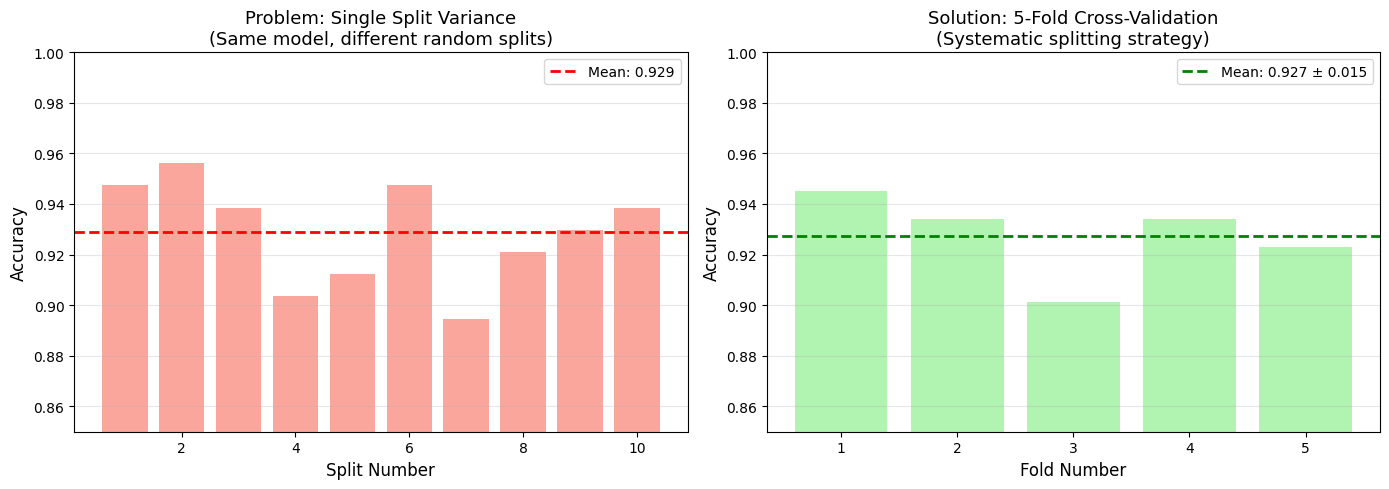

In [6]:
# Visualize the difference
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Single split variance
ax1.bar(range(1, 11), scores, alpha=0.7, color='salmon')
ax1.axhline(np.mean(scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(scores):.3f}')
ax1.set_xlabel('Split Number', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Problem: Single Split Variance\n(Same model, different random splits)', fontsize=13)
ax1.set_ylim([0.85, 1.0])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Cross-validation
ax2.bar(range(1, 6), cv_scores, alpha=0.7, color='lightgreen')
ax2.axhline(cv_scores.mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
ax2.set_xlabel('Fold Number', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Solution: 5-Fold Cross-Validation\n(Systematic splitting strategy)', fontsize=13)
ax2.set_ylim([0.85, 1.0])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---

## Part 4: Stratified vs Regular CV (for Imbalanced Data)

**Instructor narrates:** "For imbalanced datasets, we need stratified CV to maintain class proportions..."

In [8]:
# Create imbalanced dataset (90% class 0, 10% class 1)
np.random.seed(42)
n_majority = 900
n_minority = 100

X_imbalanced = np.random.randn(n_majority + n_minority, 20)
y_imbalanced = np.array([0]*n_majority + [1]*n_minority)

print(f"Imbalanced dataset: {np.bincount(y_imbalanced)} samples per class")
print(f"Class distribution: {y_imbalanced.mean()*100:.1f}% positive class\n")\

X_imbalanced

Imbalanced dataset: [900 100] samples per class
Class distribution: 10.0% positive class



array([[ 0.49671415, -0.1382643 ,  0.64768854, ...,  0.31424733,
        -0.90802408, -1.4123037 ],
       [ 1.46564877, -0.2257763 ,  0.0675282 , ..., -1.95967012,
        -1.32818605,  0.19686124],
       [ 0.73846658,  0.17136828, -0.11564828, ..., -0.30921238,
         0.33126343,  0.97554513],
       ...,
       [-0.69193084,  0.48996231,  0.96006087, ..., -2.61546896,
         1.74723733,  0.55573132],
       [-0.11676412, -0.66722324, -2.87603228, ..., -1.03302885,
         0.71373522,  0.32797039],
       [ 0.96259198,  0.51259951, -0.75311158, ...,  0.37835397,
         1.71352973, -1.6199198 ]], shape=(1000, 20))

In [9]:
# Regular CV (might have imbalanced folds)
model = DecisionTreeClassifier(max_depth=3, random_state=42)
regular_cv_scores = cross_val_score(model, X_imbalanced, y_imbalanced, cv=5)

print("Regular 5-Fold CV:")
print(f"  Mean: {regular_cv_scores.mean():.3f} ± {regular_cv_scores.std():.3f}")


Regular 5-Fold CV:
  Mean: 0.890 ± 0.008


In [11]:

# TODO: Stratified CV (maintains class proportions in each fold)
# Hint: Use StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Expected: StratifiedKFold object

stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stratified_cv_scores = cross_val_score(model, X_imbalanced, y_imbalanced, cv=stratified_cv)

print("\nStratified 5-Fold CV:")
print(f"  Mean: {stratified_cv_scores.mean():.3f} ± {stratified_cv_scores.std():.3f}")

print("\n✅ For imbalanced data, ALWAYS use StratifiedKFold!")
print("💡 Note: Even without scaling, we can demonstrate CV concepts with Decision Trees!")


Stratified 5-Fold CV:
  Mean: 0.894 ± 0.009

✅ For imbalanced data, ALWAYS use StratifiedKFold!
💡 Note: Even without scaling, we can demonstrate CV concepts with Decision Trees!


## Key Takeaways

✅ **Never trust a single train/test split** - it can vary by 3-5 percentage points just due to randomness

✅ **Always use cross-validation** - gives reliable performance estimate by averaging across multiple splits

✅ **Scale AFTER splitting** - fit scaler on training data only to prevent data leakage

✅ **Report mean ± std dev** - e.g., "Accuracy: 0.932 ± 0.015" (not just "0.932")

✅ **Use StratifiedKFold for imbalanced data** - maintains class proportions in each fold

✅ **Typical choice: 5-fold CV** - good balance between computational cost and reliability

⚠️ **Coming up in Segment 7:** Learn how to properly combine preprocessing (like scaling) with CV using **Pipelines**!

---

**Next:** Hyperparameter tuning with GridSearchCV!